In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akuadhan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:05<00:00, 140MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print(data_df["labels"].unique())
print(f"Total data: {len(data_df)}")
print("\nDistribusi kelas:")
print(data_df["labels"].value_counts())
data_df.head()

['cat' 'wild' 'dog']
Total data: 16130

Distribusi kelas:
labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [ ]:
train = data_df.sample(frac=0.70, random_state=42)
remaining = data_df.drop(train.index)

val = remaining.sample(frac=0.50, random_state=42)
test = remaining.drop(val.index)

print(f"Train size : {train.shape[0]}")
print(f"Val size   : {val.shape[0]}")
print(f"Test size  : {test.shape[0]}")

print("\nDistribusi train:")
print(train["labels"].value_counts())

Train size : 11291
Val size   : 2420
Test size  : 2419

Distribusi train:
labels
cat     4000
wild    3658
dog     3633
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

print("Mapping Label:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

Mapping Label:
  0: cat
  1: dog
  2: wild


In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform
    self.labels = torch.tensor(
        label_encoder.transform(dataframe["labels"])
    ).to(device)

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert("RGB")
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

In [ ]:
train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=val_test_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=val_test_transform)

In [ ]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 20
PATIENCE = 5

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
from torchvision import models

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.base_model = models.mobilenet_v2(weights="DEFAULT")

        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, len(label_encoder.classes_))
        )

    def forward(self, x):
        return self.base_model(x)

model = Net().to(device)
print("Model MobileNetV2 siap.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]

Model MobileNetV2 siap.


In [ ]:
train_labels_encoded = label_encoder.transform(train["labels"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_encoded),
    y=train_labels_encoded
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {dict(zip(label_encoder.classes_, class_weights.round(4)))}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)

Class weights: {'cat': np.float64(0.9409), 'dog': np.float64(1.036), 'wild': np.float64(1.0289)}


In [ ]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [ ]:
total_loss_train_plot      = []
total_loss_validation_plot = []
total_acc_train_plot       = []
total_acc_validation_plot  = []

In [ ]:
best_val_loss    = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
  model.train()
  total_acc_train  = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs    = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()
  total_loss_val = 0
  total_acc_val  = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs  = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss   = total_loss_val   / len(val_loader)
  avg_train_acc  = (total_acc_train / len(train_dataset)) * 100
  avg_val_acc    = (total_acc_val   / len(val_dataset))   * 100

  total_loss_train_plot.append(round(avg_train_loss, 4))
  total_loss_validation_plot.append(round(avg_val_loss, 4))
  total_acc_train_plot.append(round(avg_train_acc, 4))
  total_acc_validation_plot.append(round(avg_val_acc, 4))

  print(f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}%")

  scheduler.step(avg_val_loss)

  if avg_val_loss < best_val_loss:
    best_val_loss    = avg_val_loss
    patience_counter = 0
    best_model_state = model.state_dict()
    print(f"  → Val loss membaik! Model disimpan.")
  else:
    patience_counter += 1
    print(f"  → Tidak ada peningkatan. Patience: {patience_counter}/{PATIENCE}")
    if patience_counter >= PATIENCE:
      print(f"\nEarly Stopping aktif di Epoch {epoch+1}!")
      break

model.load_state_dict(best_model_state)
print("\nTraining selesai. Model terbaik sudah di-load.")

Epoch 1/20 | Train Loss: 0.1918 | Train Acc: 94.50% | Val Loss: 0.0172 | Val Acc: 99.75%
  → Val loss membaik! Model disimpan.
Epoch 2/20 | Train Loss: 0.0383 | Train Acc: 98.80% | Val Loss: 0.0147 | Val Acc: 99.67%
  → Val loss membaik! Model disimpan.
Epoch 3/20 | Train Loss: 0.0261 | Train Acc: 99.23% | Val Loss: 0.0080 | Val Acc: 99.75%
  → Val loss membaik! Model disimpan.
Epoch 4/20 | Train Loss: 0.0232 | Train Acc: 99.20% | Val Loss: 0.0072 | Val Acc: 99.79%
  → Val loss membaik! Model disimpan.
Epoch 5/20 | Train Loss: 0.0168 | Train Acc: 99.49% | Val Loss: 0.0086 | Val Acc: 99.79%
  → Tidak ada peningkatan. Patience: 1/5
Epoch 6/20 | Train Loss: 0.0143 | Train Acc: 99.51% | Val Loss: 0.0079 | Val Acc: 99.83%
  → Tidak ada peningkatan. Patience: 2/5
Epoch 7/20 | Train Loss: 0.0100 | Train Acc: 99.71% | Val Loss: 0.0060 | Val Acc: 99.79%
  → Val loss membaik! Model disimpan.
Epoch 8/20 | Train Loss: 0.0103 | Train Acc: 99.69% | Val Loss: 0.0043 | Val Acc: 99.88%
  → Val loss mem

In [ ]:
model.eval()
with torch.no_grad():
  total_loss_test = 0
  total_acc_test  = 0
  for inputs, labels in test_loader:
    predictions     = model(inputs)
    acc             = (torch.argmax(predictions, axis=1) == labels).sum().item()
    total_acc_test += acc
    test_loss       = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Test Accuracy: {round((total_acc_test / len(test_dataset)) * 100, 4)}%")
print(f"Test Loss    : {round(total_loss_test / len(test_loader), 4)}")

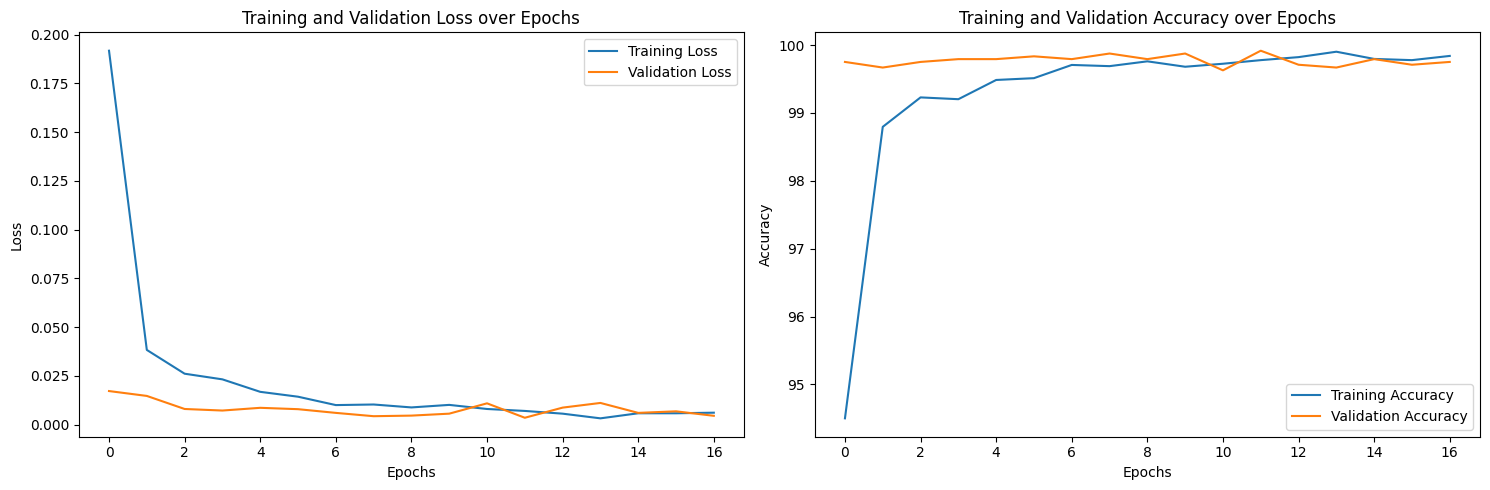

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot,      label="Training Loss")
axs[0].plot(total_loss_validation_plot, label="Validation Loss")
axs[0].set_title("Training and Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot,      label="Training Accuracy")
axs[1].plot(total_acc_validation_plot, label="Validation Accuracy")
axs[1].set_title("Training and Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "animal_classifier_optimized.pth")
print("Model disimpan sebagai 'animal_classifier_optimized.pth'")

In [ ]:
def predict_image(image_path):
    model.eval()
    img = Image.open(image_path).convert("RGB")

    input_tensor = val_test_transform(img).to(device).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)[0]

    plt.imshow(img)
    plt.title(f"File: {image_path.split("/")[-1]}")
    plt.axis("off")
    plt.show()

    print("Confidence Scores:")
    for i, label in enumerate(label_encoder.classes_):
        score = probs[i].item() * 100
        bar = "█" * int(score // 5)
        print(f"  {label:<6}: {score:6.2f}%  {bar}")

    predicted_idx = torch.argmax(probs).item()
    predicted_label = label_encoder.classes_[predicted_idx]
    print(f"\n→ Prediksi: {predicted_label.upper()}")
    return predicted_label

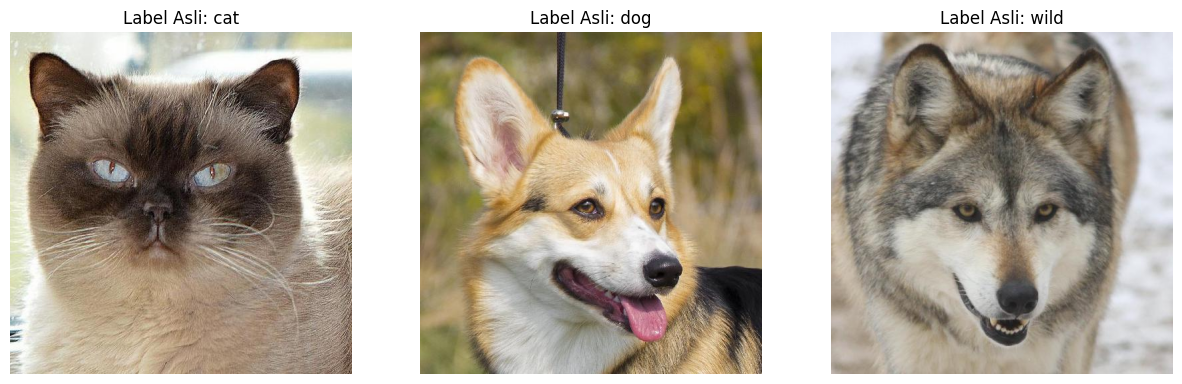

In [ ]:
def visualize_dataset_samples(df, n=3):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        sample = df.sample(1).iloc[0]
        img = Image.open(sample["image_path"])
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"Label Asli: {sample['labels']}")
        plt.axis("off")
    plt.show()

visualize_dataset_samples(train)

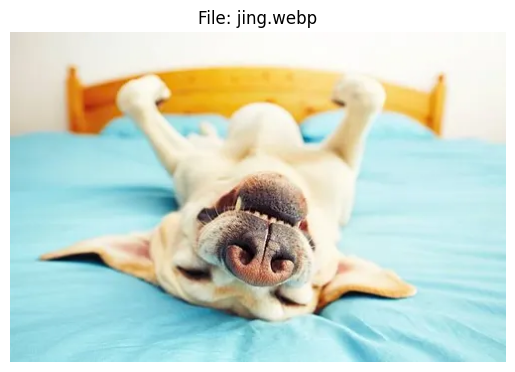

Confidence Scores:
  cat   :   0.00%  
  dog   : 100.00%  ███████████████████
  wild  :   0.00%  

→ Prediksi: DOG


'dog'

In [ ]:
predict_image("/content/jing.webp")